# Análise Exploratória de Dados (EDA)
## Bank Marketing Dataset: Datathon POSTECH MLET

**Objetivo deste notebook:** entender a base [Bank Marketing (Kaggle,
henriqueyamahata)](https://www.kaggle.com/datasets/henriqueyamahata/bank-marketing)
antes de treinar qualquer modelo, conhecer suas colunas, checar qualidade
dos dados, entender o desbalanceamento do target e identificar problemas
(vazamento temporal, outliers) e padrões de comportamento por segmento de
cliente. As decisões tomadas aqui (o que remover, como tratar) alimentam
diretamente `src/data_preparation.py` e a escolha de segmentação usada pelo
Thompson Sampling em `02_baseline_thompson.ipynb`.

O dataset descreve campanhas de telemarketing de um banco português
oferecendo um depósito a prazo, é a base usada como proxy para o problema do
desafio (decidir, por cliente, se vale a pena ofertar um produto).

In [1]:
# Importações
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings

warnings.filterwarnings('ignore')

# Configuração de estilo
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


## 1. Carregar e Inspecionar Dados

Carregamos o CSV bruto baixado do Kaggle (separador `;`) e fazemos uma
primeira inspeção: dimensões, tipos de cada coluna, estatísticas descritivas
e checagem de valores faltantes, antes de qualquer tratamento.

In [2]:
# Carregar dados
df = pd.read_csv('../data/raw/bank-additional-full.csv', sep=';')

print(f"Dimensões do dataset: {df.shape}")
print(f"   - Linhas (clientes): {df.shape[0]:,}")
print(f"   - Colunas (features): {df.shape[1]}")
print(f"\nPrimeiras 5 linhas:")
df.head()

Dimensões do dataset: (41188, 21)
   - Linhas (clientes): 41,188
   - Colunas (features): 21

Primeiras 5 linhas:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
# Informações sobre tipos de dados
print("Informações sobre o dataset:")
print(df.info())

Informações sobre o dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             41188 non-null  int64
 1   job             41188 non-null  object
 2   marital         41188 non-null  object
 3   education       41188 non-null  object
 4   default         41188 non-null  object
 5   housing         41188 non-null  object
 6   loan            41188 non-null  object
 7   contact         41188 non-null  object
 8   month           41188 non-null  object
 9   day_of_week     41188 non-null  object
 10  duration        41188 non-null  int64
 11  campaign        41188 non-null  int64
 12  pdays           41188 non-null  int64
 13  previous        41188 non-null  int64
 14  poutcome        41188 non-null  object
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-

In [4]:
# Estatísticas descritivas
print("Estatísticas Descritivas:")
df.describe()

Estatísticas Descritivas:


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [5]:
# Verificar valores faltantes
print("Valores faltantes por coluna:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("   Nenhum valor faltante encontrado!")
else:
    print(missing[missing > 0])

Valores faltantes por coluna:
   Nenhum valor faltante encontrado!


In [6]:
# Listar todas as colunas
print("Todas as colunas do dataset:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col:20s} ({df[col].dtype})")

Todas as colunas do dataset:
   1. age                  (int64)
   2. job                  (object)
   3. marital              (object)
   4. education            (object)
   5. default              (object)
   6. housing              (object)
   7. loan                 (object)
   8. contact              (object)
   9. month                (object)
  10. day_of_week          (object)
  11. duration             (int64)
  12. campaign             (int64)
  13. pdays                (int64)
  14. previous             (int64)
  15. poutcome             (object)
  16. emp.var.rate         (float64)
  17. cons.price.idx       (float64)
  18. cons.conf.idx        (float64)
  19. euribor3m            (float64)
  20. nr.employed          (float64)
  21. y                    (object)


**Achado:** 41.188 clientes, 21 colunas, **nenhum valor faltante**: não é
necessário imputar nada, o que elimina uma fonte comum de retrabalho na
preparação dos dados. As colunas combinam dados demográficos (`age`, `job`,
`marital`, `education`), financeiros (`default`, `housing`, `loan`), de
campanha (`contact`, `month`, `campaign`, `pdays`, `previous`, `poutcome`) e
indicadores macroeconômicos do período (`emp.var.rate`, `euribor3m`, etc.).

## 2. Analisar Variável Target (y)

A variável alvo `y` indica se o cliente aceitou o depósito a prazo ofertado
na campanha. Entender seu desbalanceamento é essencial: ele explica, por
exemplo, por que um baseline "sempre ofertar" tem taxa de aceitação baixa, e
por que o split treino/teste precisa ser estratificado (Etapa 2).

In [7]:
# Verificar coluna alvo
print("Variável Target ('y' - Aceitou a oferta?):")
print(f"   Valores únicos: {df['y'].unique()}")
print(f"\n   Distribuição:")
print(df['y'].value_counts())
print(f"\n   Proporção:")
proporções = df['y'].value_counts(normalize=True) * 100
for classe, pct in proporções.items():
    print(f"   {classe}: {pct:.2f}%")

Variável Target ('y' - Aceitou a oferta?):
   Valores únicos: ['no' 'yes']

   Distribuição:
y
no     36548
yes     4640
Name: count, dtype: int64

   Proporção:
   no: 88.73%
   yes: 11.27%


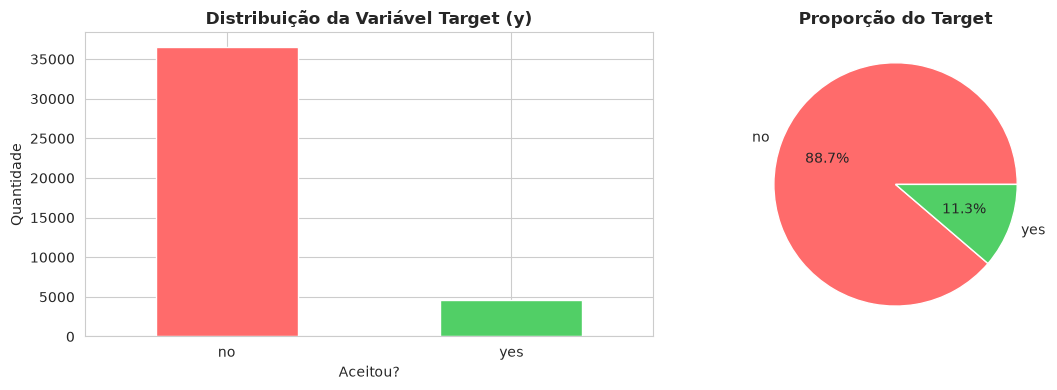


Observação: Dataset é DESBALANCEADO
   - Taxa de 'yes' (aceitação): 11.3%
   - Taxa de 'no' (rejeição): 88.7%


In [8]:
# Visualizar distribuição do target
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico 1: Contagem
df['y'].value_counts().plot(kind='bar', ax=axes[0], color=['#ff6b6b', '#51cf66'])
axes[0].set_title('Distribuição da Variável Target (y)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Quantidade')
axes[0].set_xlabel('Aceitou?')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Gráfico 2: Pizza
df['y'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                            colors=['#ff6b6b', '#51cf66'])
axes[1].set_title('Proporção do Target', fontsize=12, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print(f"\nObservação: Dataset é DESBALANCEADO")
print(f"   - Taxa de 'yes' (aceitação): {(df['y']=='yes').sum() / len(df) * 100:.1f}%")
print(f"   - Taxa de 'no' (rejeição): {(df['y']=='no').sum() / len(df) * 100:.1f}%")

**Achado:** apenas **~11% dos clientes aceitam** a oferta, dataset
fortemente desbalanceado. Isso define a régua de comparação: um baseline
"sempre ofertar" converge para ~11% de taxa de aceitação real; qualquer
estratégia adaptativa só se justifica se conseguir superar esse número
concentrando o contato nos clientes certos (ver notebook `02`).

## 3. Analisar Features (Características)

Separamos as features em numéricas (idade, indicadores macroeconômicos) e
categóricas (profissão, estado civil, etc.) e olhamos suas distribuições e
correlação com o target, para identificar quais sinais são mais informativos
para segmentar os clientes.

In [9]:
# Separar features numéricas e categóricas
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Remover target do categorical
categorical_cols.remove('y')

print(f"Features Numéricas ({len(numeric_cols)}):")
print(f"   {numeric_cols}")
print(f"\nFeatures Categóricas ({len(categorical_cols)}):")
print(f"   {categorical_cols}")

Features Numéricas (10):
   ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Features Categóricas (10):
   ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


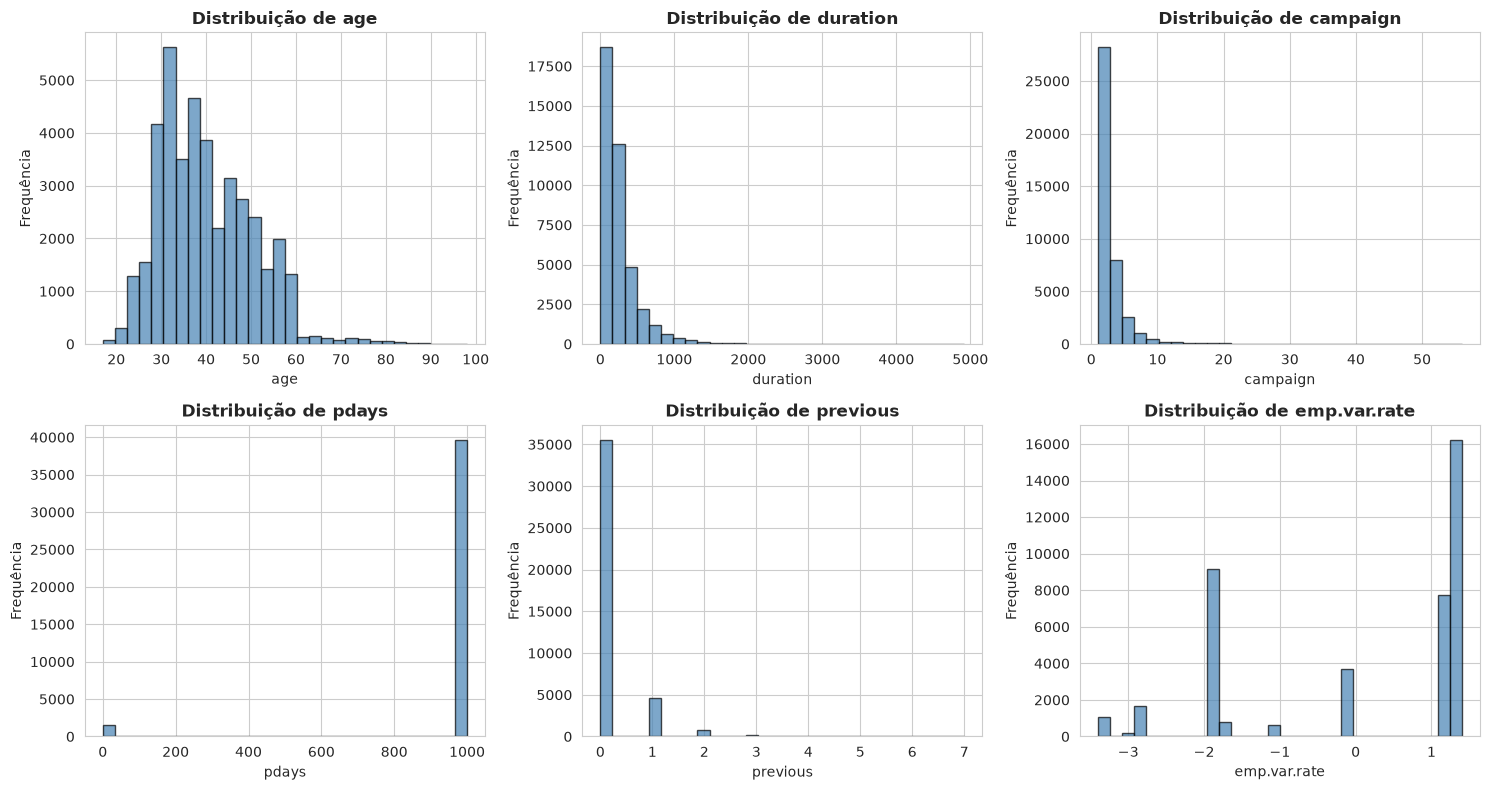

Distribuições de features numéricas visualizadas


In [10]:
# Visualizar distribuições de features numéricas
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols[:6]):
    axes[idx].hist(df[col], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribuição de {col}', fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequência')

plt.tight_layout()
plt.show()

print(f"Distribuições de features numéricas visualizadas")

In [11]:
# Análise de features categóricas principais
print("Top Features Categóricas:")
for col in categorical_cols[:5]:
    print(f"\n   {col}:")
    print(f"   Valores únicos: {df[col].nunique()}")
    print(f"   Top 3: {df[col].value_counts().head(3).to_dict()}")

Top Features Categóricas:

   job:
   Valores únicos: 12
   Top 3: {'admin.': 10422, 'blue-collar': 9254, 'technician': 6743}

   marital:
   Valores únicos: 4
   Top 3: {'married': 24928, 'single': 11568, 'divorced': 4612}

   education:
   Valores únicos: 8
   Top 3: {'university.degree': 12168, 'high.school': 9515, 'basic.9y': 6045}

   default:
   Valores únicos: 3
   Top 3: {'no': 32588, 'unknown': 8597, 'yes': 3}

   housing:
   Valores únicos: 3
   Top 3: {'yes': 21576, 'no': 18622, 'unknown': 990}


Top 10 Features Correlacionadas com Target:
duration          0.405274
previous          0.230181
cons.conf.idx     0.054878
age               0.030399
campaign         -0.066357
cons.price.idx   -0.136211
emp.var.rate     -0.298334
euribor3m        -0.307771
pdays            -0.324914
nr.employed      -0.354678
Name: y_binary, dtype: float64


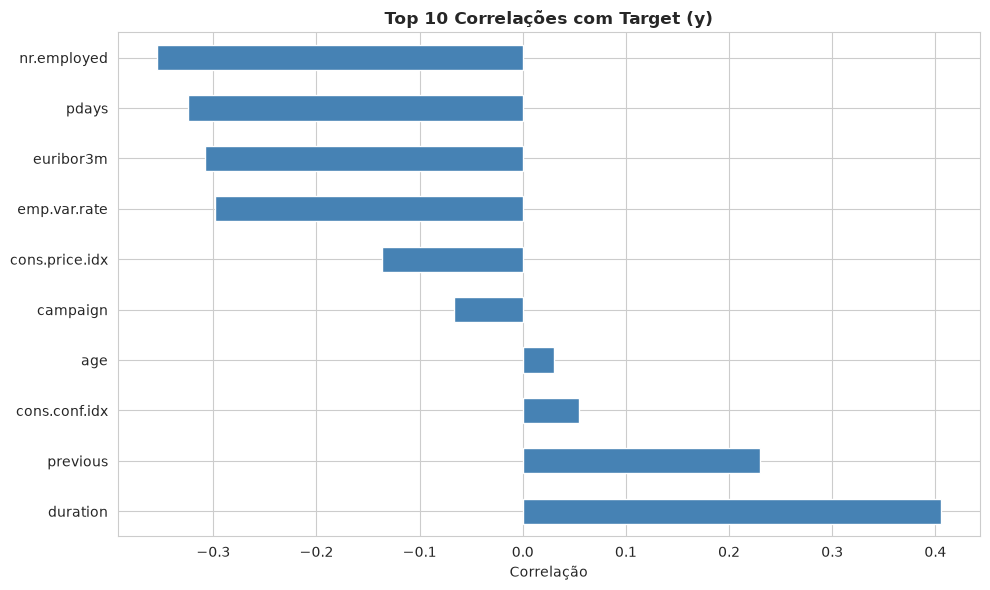

In [12]:
# Correlações com target (converteremos y em 0/1)
df_corr = df.copy()
df_corr['y_binary'] = (df_corr['y'] == 'yes').astype(int)

correlations = df_corr[numeric_cols + ['y_binary']].corr()['y_binary'].drop('y_binary').sort_values(ascending=False)

print("Top 10 Features Correlacionadas com Target:")
print(correlations.head(10))

# Visualizar
fig, ax = plt.subplots(figsize=(10, 6))
correlations.head(10).plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 10 Correlações com Target (y)', fontsize=12, fontweight='bold')
ax.set_xlabel('Correlação')
plt.tight_layout()
plt.show()

**Achado:** fora `duration` (tratada à parte abaixo, é vazamento), as
correlações mais fortes vêm de variáveis ligadas ao **histórico de contato**
(`pdays`, `previous`) e a **indicadores macroeconômicos** do período da
campanha (`emp.var.rate`, `euribor3m`, `nr.employed`), sinal de que o
contexto econômico e o histórico prévio pesam tanto quanto o perfil
individual do cliente.

## 4. Verificar Problemas (Vazamento Temporal, Outliers)

Antes de treinar qualquer modelo, verificamos dois problemas clássicos:
**vazamento temporal** (uma feature que só existe depois de sabermos o
resultado, o que tornaria o modelo enganosamente bom) e **outliers** que
possam distorcer a normalização das features numéricas.

In [13]:
# Coluna 'duration' é suspeita (pode ser vazamento)
print("Verificando Vazamento Temporal:")
print(f"   A coluna 'duration' (tempo de chamada) está no dataset.")
print(f"   PROBLEMA: duration não é conhecido antes de ofertar.")
print(f"   SOLUÇÃO: Remover 'duration' antes de treinar o modelo.")
print(f"\n   Correlação de 'duration' com 'y': {df_corr['duration'].corr(df_corr['y_binary']):.3f}")
print(f"   (Muito alta! Confirma que é vazamento.)")

Verificando Vazamento Temporal:
   A coluna 'duration' (tempo de chamada) está no dataset.
   PROBLEMA: duration não é conhecido antes de ofertar.
   SOLUÇÃO: Remover 'duration' antes de treinar o modelo.

   Correlação de 'duration' com 'y': 0.405
   (Muito alta! Confirma que é vazamento.)


In [14]:
# Verificar outliers em features numéricas
print("Análise de Outliers (usando IQR):")
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    if outliers > 0:
        print(f"   {col}: {outliers} outliers ({outliers/len(df)*100:.1f}%)")

Análise de Outliers (usando IQR):
   age: 469 outliers (1.1%)
   duration: 2963 outliers (7.2%)
   campaign: 2406 outliers (5.8%)
   pdays: 1515 outliers (3.7%)
   previous: 5625 outliers (13.7%)
   cons.conf.idx: 447 outliers (1.1%)


**Achado:** `duration` (duração da ligação) tem correlação altíssima com o
target porque só é conhecida **depois** da ligação acontecer, usá-la como
feature seria vazamento de informação do futuro. Por isso ela é descartada em
`src/data_preparation.py` antes do treino. Os outliers encontrados são
esperados em variáveis de contagem/tempo (`campaign`, `pdays`, `previous`) e
não indicam erro de coleta; mantemos os valores e deixamos a normalização
(`StandardScaler`) absorver a escala.

## 5. Análise de Padrões (Quem Aceita Mais?)

Por fim, cruzamos o target com três variáveis demográficas, idade,
profissão e estado civil, para identificar os comportamentos distintos que
o Thompson Sampling contextual (notebook `02`) vai aprender a diferenciar por
segmento.

Taxa de Aceitação por Faixa de Idade:
age_group
18-25    20.948379
26-35    11.719539
36-45     8.509810
46-55     8.691963
56-65    15.221060
65+      46.849758
Name: y, dtype: float64


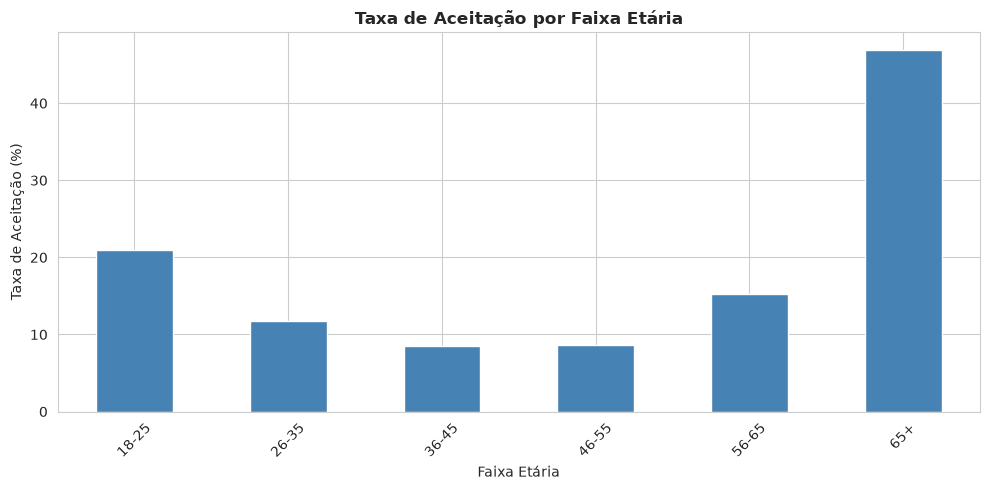

In [15]:
# Aceitar por faixa de idade
df['age_group'] = pd.cut(df['age'], bins=[0, 25, 35, 45, 55, 65, 100],
                          labels=['18-25', '26-35', '36-45', '46-55', '56-65', '65+'])

print("Taxa de Aceitação por Faixa de Idade:")
age_aceitacao = df.groupby('age_group')['y'].apply(lambda x: (x=='yes').sum() / len(x) * 100)
print(age_aceitacao)

# Visualizar
fig, ax = plt.subplots(figsize=(10, 5))
age_aceitacao.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Taxa de Aceitação por Faixa Etária', fontsize=12, fontweight='bold')
ax.set_ylabel('Taxa de Aceitação (%)')
ax.set_xlabel('Faixa Etária')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
plt.tight_layout()
plt.show()

Taxa de Aceitação por Profissão (Top 10):
job
student          31.428571
retired          25.232558
unemployed       14.201183
admin.           12.972558
management       11.217510
unknown          11.212121
technician       10.826042
self-employed    10.485574
housemaid        10.000000
entrepreneur      8.516484
Name: y, dtype: float64


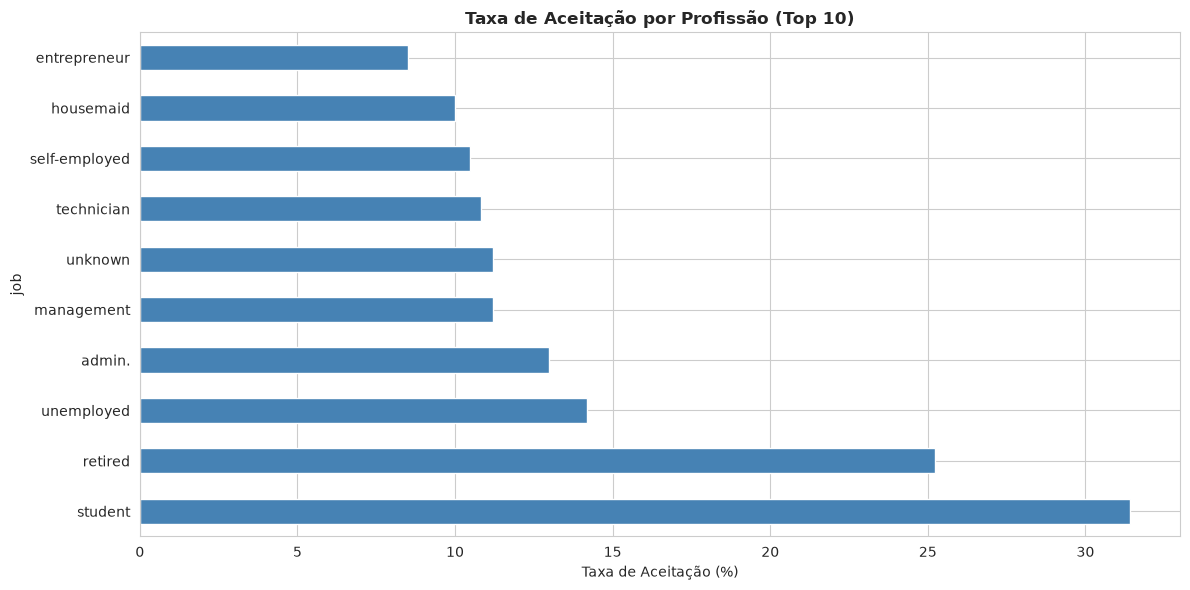

In [16]:
# Aceitar por profissão (top 10)
print("Taxa de Aceitação por Profissão (Top 10):")
job_aceitacao = df.groupby('job')['y'].apply(lambda x: (x=='yes').sum() / len(x) * 100).sort_values(ascending=False)
print(job_aceitacao.head(10))

# Visualizar
fig, ax = plt.subplots(figsize=(12, 6))
job_aceitacao.head(10).plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Taxa de Aceitação por Profissão (Top 10)', fontsize=12, fontweight='bold')
ax.set_xlabel('Taxa de Aceitação (%)')
plt.tight_layout()
plt.show()

Taxa de Aceitação por Estado Civil:
marital
divorced    10.320902
married     10.157253
single      14.004149
unknown     15.000000
Name: y, dtype: float64


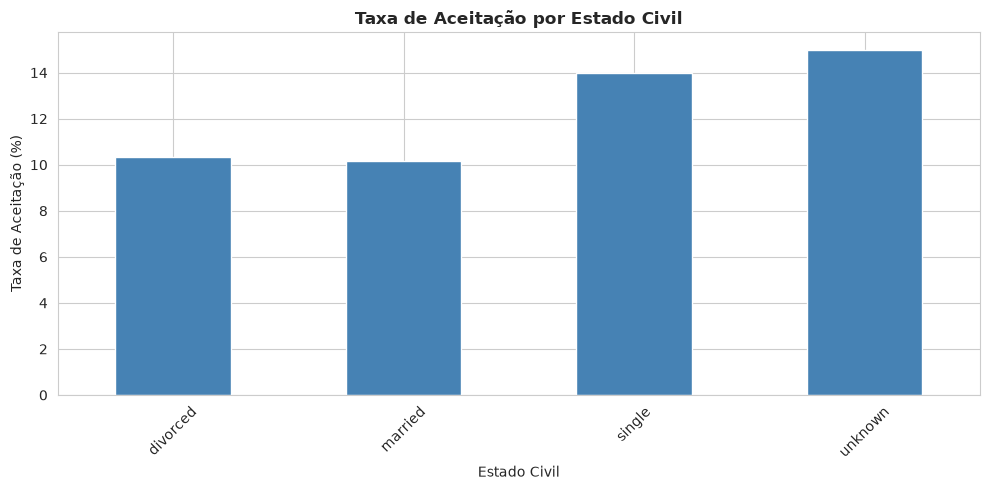

In [17]:
# Aceitar por estado civil
print("Taxa de Aceitação por Estado Civil:")
marital_aceitacao = df.groupby('marital')['y'].apply(lambda x: (x=='yes').sum() / len(x) * 100)
print(marital_aceitacao)

# Visualizar
fig, ax = plt.subplots(figsize=(10, 5))
marital_aceitacao.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Taxa de Aceitação por Estado Civil', fontsize=12, fontweight='bold')
ax.set_ylabel('Taxa de Aceitação (%)')
ax.set_xlabel('Estado Civil')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
plt.tight_layout()
plt.show()

**Achado:** clientes **65+** e profissões como **student** e **retired**
aceitam com taxas bem acima da média geral (~11%), muitas vezes 3-4x maior.
Esse é exatamente o tipo de comportamento distinto entre segmentos que
justifica um Thompson Sampling **contextual**: em vez de uma única
propensão global, o modelo aprende uma posterior por combinação de idade e
profissão (ver `02_baseline_thompson.ipynb`), concentrando as ofertas nesses
segmentos de maior propensão.

## RESUMO DA EDA

In [18]:
print("="*70)
print("RESUMO DA ANÁLISE EXPLORATÓRIA")
print("="*70)

print(f"\nDATASET:")
print(f"   Total de clientes: {len(df):,}")
print(f"   Features: {len(df.columns)-1}")
print(f"   Numéricas: {len(numeric_cols)}")
print(f"   Categóricas: {len(categorical_cols)}")

print(f"\nTARGET (y):")
print(f"   'Yes' (aceitou): {(df['y']=='yes').sum():,} ({(df['y']=='yes').sum()/len(df)*100:.1f}%)")
print(f"   'No' (rejeitou): {(df['y']=='no').sum():,} ({(df['y']=='no').sum()/len(df)*100:.1f}%)")
print(f"   Dataset DESBALANCEADO (mais rejeições)")

print(f"\nTOP 3 FEATURES CORRELACIONADAS:")
for i, (feat, corr) in enumerate(correlations.head(3).items(), 1):
    print(f"   {i}. {feat}: {corr:.3f}")

print(f"\nPROBLEMAS IDENTIFICADOS:")
print(f"   1. 'duration' -> VAZAMENTO TEMPORAL (remover antes de treinar)")
print(f"   2. Dataset desbalanceado -> usar stratified split")
print(f"   3. Sem valores faltantes ")

print(f"\nPRÓXIMOS PASSOS:")
print(f"   1. Remover 'duration'")
print(f"   2. Codificar variáveis categóricas")
print(f"   3. Normalizar features numéricas")
print(f"   4. Split em treino/teste (stratified)")
print(f"   5. Implementar Baseline e Thompson Sampling")
print("="*70)

RESUMO DA ANÁLISE EXPLORATÓRIA

DATASET:
   Total de clientes: 41,188
   Features: 21
   Numéricas: 10
   Categóricas: 10

TARGET (y):
   'Yes' (aceitou): 4,640 (11.3%)
   'No' (rejeitou): 36,548 (88.7%)
   Dataset DESBALANCEADO (mais rejeições)

TOP 3 FEATURES CORRELACIONADAS:
   1. duration: 0.405
   2. previous: 0.230
   3. cons.conf.idx: 0.055

PROBLEMAS IDENTIFICADOS:
   1. 'duration' -> VAZAMENTO TEMPORAL (remover antes de treinar)
   2. Dataset desbalanceado -> usar stratified split
   3. Sem valores faltantes

PRÓXIMOS PASSOS:
   1. Remover 'duration'
   2. Codificar variáveis categóricas
   3. Normalizar features numéricas
   4. Split em treino/teste (stratified)
   5. Implementar Baseline e Thompson Sampling


---
**Próximo passo:** `src/data_preparation.py` aplica essas decisões (remove
`duration`, codifica categorias, normaliza e faz o split estratificado) e
`02_baseline_thompson.ipynb` treina e compara o Baseline com o Thompson
Sampling contextual usando os segmentos de idade + profissão identificados
aqui.